# **5.** Hafta

Sklearn 'diabetes' veri setini yükleyerek, veriyi eğitim ve test setlerine ayırıp, sırasıyla Lineer Regresyon ve k-NN Regresyon (k=5) modellerini eğitelim. Her iki model için MAE, MSE ve RMSE hata metriklerini hesaplayıp, performanslarını karşılaştalım.

## Veri Seti Yükleme ve Hazırlama

### Scikit-Learn Kütüphanesine [Bu Linkten](https://scikit-learn.org/stable/) ulaşabilirsiniz. Ayrıca kütüphane içerisindeki veri setlerine [Bu Linkten](https://scikit-learn.org/stable/api/sklearn.datasets.html) ulaşabilirsiniz.




### **1.** Sklearn'den 'diabetes' veri setini yükleyelim ve özellikleri (X) ve hedef değişkeni (y) ayıralım.

`sklearn.datasets.load_diabetes` fonksiyonunu kullanacağız.


* Girdiler (Özellikler - X)

Bu veri seti, hastalara ait 10 adet fizyolojik özelliği içermektedir.
Bu özellikler makine öğrenmesi modeline giriş olarak verilir ve hedef değişkenin tahmin edilmesinde kullanılır.

Özellikler şunlardır:

1. Yaş (Age)

2. Cinsiyet (Sex)

3. Vücut Kitle İndeksi (BMI)

4. Ortalama Kan Basıncı (Blood Pressure)

5. S1 – Serum ölçümü 1

6. S2 – Serum ölçümü 2

7. S3 – Serum ölçümü 3

8. S4 – Serum ölçümü 4

9. S5 – Serum ölçümü 5

10. S6 – Serum ölçümü 6

Bu 10 özellik, modelin bağımsız değişkenlerini (X matrisi) oluşturur.


* Çıktı (Hedef - y)

Bu veri setinde tahmin edilmek istenen değer:

`Hastalığın ilerleme skoru`dur.

In [2]:
# 0. Gerekli kütüphaneyi yükle
from sklearn.datasets import load_diabetes

# 1. 'diabetes' veri setini yükle
diabetes = load_diabetes()

# 2. Özellikleri (X) ve hedef değişkeni (y) ayır
X = diabetes.data
y = diabetes.target

# Veri setinin boyutlarını kontrol edelim
print(f"Orijinal X boyutu: {X.shape}")
print(f"Orijinal y boyutu: {y.shape}\n")

Orijinal X boyutu: (442, 10)
Orijinal y boyutu: (442,)



### **2.** Veriyi %80 eğitim, %20 test olarak bölelim.

`sklearn.model_selection.train_test_split` fonksiyonunu kullanacağız.

In [3]:
# 0. Gerekli kütüphaneyi yükle
from sklearn.model_selection import train_test_split

# 3. Veriyi eğitim ve test setlerine böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Bölünmüş veri setlerinin boyutlarını kontrol edelim
print(f"X_train boyutu: {X_train.shape}")
print(f"X_test boyutu: {X_test.shape}")
print(f"y_train boyutu: {y_train.shape}")
print(f"y_test boyutu: {y_test.shape}")

X_train boyutu: (353, 10)
X_test boyutu: (89, 10)
y_train boyutu: (353,)
y_test boyutu: (89,)


In [8]:
y_test

array([219.,  70., 202., 230., 111.,  84., 242., 272.,  94.,  96.,  94.,
       252.,  99., 297., 135.,  67., 295., 264., 170., 275., 310.,  64.,
       128., 232., 129., 118., 263.,  77.,  48., 107., 140., 113.,  90.,
       164., 180., 233.,  42.,  84., 172.,  63.,  48., 108., 156., 168.,
        90.,  52., 200.,  87.,  90., 258., 136., 158.,  69.,  72., 171.,
        95.,  72., 151., 168.,  60., 122.,  52., 187., 102., 214., 248.,
       181., 110., 140., 202., 101., 222., 281.,  61.,  89.,  91., 186.,
       220., 237., 233.,  68., 190.,  96.,  72., 153.,  98.,  37.,  63.,
       184.])

## Lineer Regresyon Modeli Oluşturma

Eğitim verisi üzerinde bir Lineer Regresyon modeli eğitecek, test verisi üzerinde tahminler yapacak ve MAE, MSE, RMSE gibi hata metriklerini hesaplayacağız.

### Eğitim

In [11]:
# 0. Gerekli kütüphaneyi yükle
from sklearn.linear_model import LinearRegression

# 1. Lineer Regresyon modelini oluştur
linear_model = LinearRegression()

# 2. Modeli eğitim verisi üzerinde eğit
linear_model.fit(X_train, y_train)

LinearRegression()

### Lineer Modelin Katsayıları

In [16]:
coefficients = linear_model.coef_
intercept = linear_model.intercept_

equation = "y = "

for i, coef in enumerate(coefficients):
    equation += f"{coef:.4f} * x{i+1} + "

equation += f"{intercept:.4f}"

print("Model Denklemi:")
print(equation)

Model Denklemi:
y = 37.9040 * x1 + -241.9644 * x2 + 542.4288 * x3 + 347.7038 * x4 + -931.4888 * x5 + 518.0623 * x6 + 163.4200 * x7 + 275.3179 * x8 + 736.1989 * x9 + 48.6707 * x10 + 151.3456


### Tahmin

In [17]:
# 3. Test verisi üzerinde tahminler yap
y_pred_lr = linear_model.predict(X_test)

In [18]:
y_test

array([219.,  70., 202., 230., 111.,  84., 242., 272.,  94.,  96.,  94.,
       252.,  99., 297., 135.,  67., 295., 264., 170., 275., 310.,  64.,
       128., 232., 129., 118., 263.,  77.,  48., 107., 140., 113.,  90.,
       164., 180., 233.,  42.,  84., 172.,  63.,  48., 108., 156., 168.,
        90.,  52., 200.,  87.,  90., 258., 136., 158.,  69.,  72., 171.,
        95.,  72., 151., 168.,  60., 122.,  52., 187., 102., 214., 248.,
       181., 110., 140., 202., 101., 222., 281.,  61.,  89.,  91., 186.,
       220., 237., 233.,  68., 190.,  96.,  72., 153.,  98.,  37.,  63.,
       184.])

In [19]:
y_pred_lr

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872,  92.1723465 , 258.23238899, 181.33732057,
        90.22411311, 108.63375858,  94.13865744, 168.43486358,
        53.5047888 , 206.63081659, 100.12925869, 130.66657085,
       219.53071499, 250.7803234 , 196.3688346 , 218.57511815,
       207.35050182,  88.48340941,  70.43285917, 188.95914235,
       154.8868162 , 159.36170122, 188.31263363, 180.39094033,
        47.99046561, 108.97453871, 174.77897633,  86.36406656,
       132.95761215, 184.53819483, 173.83220911, 190.35858492,
       124.4156176 , 119.65110656, 147.95168682,  59.05405241,
        71.62331856, 107.68284704, 165.45365458, 155.00975931,
       171.04799096,  61.45761356,  71.66672581, 114.96732206,
        51.57975523, 167.57599528, 152.52291955,  62.95568515,
       103.49741722, 109.20751489, 175.64118426, 154.60296242,
        94.41704366, 210.74209145, 120.2566205 ,  77.61585399,
       187.93203995, 206.49337474, 140.63167076, 105.59

### Model Hatası Hesaplama

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

# 4. Hata metriklerini hesapla
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)

# 5. Sonuçları yazdır
print("Lineer Regresyon Modeli Performansı:")
print(f"  MAE : {mae_lr:.3f}")
print(f"  MSE : {mse_lr:.3f}")
print(f"  RMSE: {rmse_lr:.3f}")

Lineer Regresyon Modeli Performansı:
  MAE : 42.794
  MSE : 2900.194
  RMSE: 53.853


## k-NN Regresyon Modeli Oluşturma

Eğitim verisi üzerinde bir k-NN Regresyon modeli (k=5) eğitelim, test verisi üzerinde tahminler yapalım ve MAE, MSE, RMSE gibi hata metriklerini hesaplayalım.

### Eğitim

In [23]:
from sklearn.neighbors import KNeighborsRegressor

# 1. k-NN Regresyon modelini oluştur (k=5)
k = 5
knn_model = KNeighborsRegressor(n_neighbors=k)

# 2. Modeli eğitim verisi üzerinde eğit
knn_model.fit(X_train, y_train)

KNeighborsRegressor()

### Tahmin

In [24]:
# 3. Test verisi üzerinde tahminler yap
y_pred_knn = knn_model.predict(X_test)

In [25]:
y_test

array([219.,  70., 202., 230., 111.,  84., 242., 272.,  94.,  96.,  94.,
       252.,  99., 297., 135.,  67., 295., 264., 170., 275., 310.,  64.,
       128., 232., 129., 118., 263.,  77.,  48., 107., 140., 113.,  90.,
       164., 180., 233.,  42.,  84., 172.,  63.,  48., 108., 156., 168.,
        90.,  52., 200.,  87.,  90., 258., 136., 158.,  69.,  72., 171.,
        95.,  72., 151., 168.,  60., 122.,  52., 187., 102., 214., 248.,
       181., 110., 140., 202., 101., 222., 281.,  61.,  89.,  91., 186.,
       220., 237., 233.,  68., 190.,  96.,  72., 153.,  98.,  37.,  63.,
       184.])

In [26]:
y_pred_knn

array([125.6, 160.2, 153. , 238. , 153.4, 150.4, 246.2, 170. , 106.6,
       104.6,  93.2, 151.6, 104. , 166.6,  61.4, 105.4, 263.8, 252. ,
       173.6, 215.4, 184.6,  86.6, 106.6, 174. , 158.2, 168. , 196.6,
       145.6,  67.6, 117.2, 158. , 166.6,  89. , 158.4, 166.4, 243.6,
        73.8, 136.8, 148.6, 106.6,  90. , 100.6, 134.2, 147.6, 193.4,
        81.6,  83.6,  90.8,  84.4, 119.2, 117.8,  88.2, 150.6, 112. ,
       210.2, 130.8,  79.4, 175.8, 120.4,  73. , 155. , 117.6,  58. ,
        94.6, 169.4, 187.4, 214.4, 146.4, 145.2, 118.8, 119.2, 195. ,
       204.4,  98.6, 107.8, 209.4, 151. , 163.6, 210.4, 218.2, 150.8,
       139. ,  67.4,  82.4, 105.4, 113.2, 110.4,  84.2, 159.2])

### Model Hatası Hesaplama

In [28]:
# 4. Hata metriklerini hesapla
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = root_mean_squared_error(y_test, y_pred_knn)

# 5. Sonuçları yazdır
print(f"k-NN Regresyon Modeli Performansı (k={k}):")
print(f"  MAE : {mae_knn:.3f}")
print(f"  MSE : {mse_knn:.3f}")
print(f"  RMSE: {rmse_knn:.3f}")

k-NN Regresyon Modeli Performansı (k=5):
  MAE : 42.771
  MSE : 3019.076
  RMSE: 54.946


## Model Performanslarını Karşılaştırma

Her iki modelin hesapladığı MAE, MSE ve RMSE değerlerini karşılaştırmalı olarak yazdıralım.


In [ ]:
print("\n--- Model Performans Karşılaştırması ---")
print("Lineer Regresyon:")
print(f"  MAE : {mae_lr:.3f}")
print(f"  MSE : {mse_lr:.3f}")
print(f"  RMSE: {rmse_lr:.3f}")

print("\nk-NN Regresyon (k=5):")
print(f"  MAE : {mae_knn:.3f}")
print(f"  MSE : {mse_knn:.3f}")
print(f"  RMSE: {rmse_knn:.3f}")


--- Model Performans Karşılaştırması ---
Lineer Regresyon:
  MAE : 42.794
  MSE : 2900.194
  RMSE: 53.853

k-NN Regresyon (k=5):
  MAE : 42.771
  MSE : 3019.076
  RMSE: 54.946


## Model Performans Karşılaştırması ve Özeti

### Sonuç:
Her iki model de diyabet veri setindeki hedef değişkeni tahmin etmek için kullanılmıştır. Performans metriklerine bakıldığında:

*   **MAE (Ortalama Mutlak Hata)**: Lineer Regresyon'un MAE değeri (42.794) ile k-NN Regresyon'un MAE değeri (42.771) birbirine oldukça yakındır. k-NN bu metrikte çok hafif bir üstünlük sağlamıştır.

*   **MSE (Ortalama Kare Hata) ve RMSE (Ortalama Kare Hatanın Karekökü)**: Bu metrikler, özellikle büyük hataları daha fazla cezalandırdığı için modelin tahminlerinin ne kadar tutarlı olduğunu gösterir. Lineer Regresyon modeli (MSE: 2900.194, RMSE: 53.853) k-NN modeline (MSE: 3019.076, RMSE: 54.946) göre biraz daha düşük MSE ve RMSE değerlerine sahiptir, bu da Lineer Regresyon'un ortalama olarak daha küçük hatalar yaptığını veya daha az büyük hata yaptığını göstermektedir.

**Genel Değerlendirme:**
Bu özel veri setinde ve seçilen k=5 değeri için, Lineer Regresyon modeli RMSE ve MSE açısından k-NN regresyona kıyasla biraz daha iyi performans göstermiştir. MAE değerleri ise neredeyse aynıdır. Bu durum, 'diabetes' veri setindeki özellikler ile hedef değişken arasında güçlü bir doğrusal ilişkinin olabileceğini veya k-NN'in bu veri setindeki karmaşık ilişkileri yakalamakta Lineer Regresyon'a göre belirgin bir avantaj sağlayamadığını düşündürebilir. Ayrıca, k-NN'in performansı seçilen `k` değerine duyarlı olduğu için, farklı `k` değerleriyle deneme yapmak daha iyi sonuçlar verebilir.

## k-NN: Farklı k Değerlerinin incelenmesi:

Farklı k Değerleri İçin k-NN MAE Sonuçları:
------------------------------------------
k = 3: MAE = 44.199
k = 5: MAE = 42.771
k = 7: MAE = 42.648
k = 9: MAE = 44.501
k = 11: MAE = 45.039
k = 13: MAE = 44.852
k = 15: MAE = 45.194
------------------------------------------


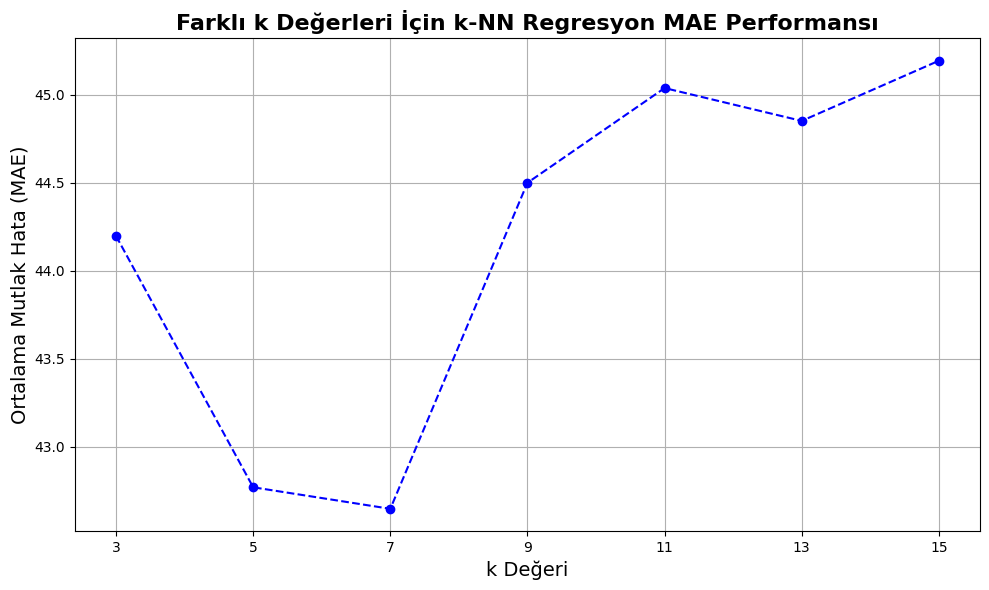

In [30]:
import matplotlib.pyplot as plt

# Test edilecek k değerleri
k_values_to_evaluate = [3, 5, 7, 9, 11, 13, 15]
mae_scores = []

print("Farklı k Değerleri İçin k-NN MAE Sonuçları:")
print("------------------------------------------")

for k in k_values_to_evaluate:
    # k-NN modelini oluştur ve eğit
    knn_model_eval = KNeighborsRegressor(n_neighbors=k)
    knn_model_eval.fit(X_train, y_train)

    # Test verisi üzerinde tahminler yap
    y_pred_knn_eval = knn_model_eval.predict(X_test)

    # MAE'yi hesapla
    mae = mean_absolute_error(y_test, y_pred_knn_eval)
    mae_scores.append(mae)

    print(f"k = {k}: MAE = {mae:.3f}")

print("------------------------------------------")

# MAE sonuçlarını görselleştir
plt.figure(figsize=(10, 6))
plt.plot(k_values_to_evaluate, mae_scores, marker='o', linestyle='--', color='blue')
plt.title('Farklı k Değerleri İçin k-NN Regresyon MAE Performansı', fontsize=16, fontweight='bold')
plt.xlabel('k Değeri', fontsize=14)
plt.ylabel('Ortalama Mutlak Hata (MAE)', fontsize=14)
plt.xticks(k_values_to_evaluate) # Sadece test edilen k değerlerini göster
plt.grid(True)
plt.tight_layout()
plt.show()